

## Task 0.
---
### Task 0.1 Imports

----

In [1]:
# Core libraries: numpy for manual maths, pandas for the small CSVs, torch for the NNs,
# matplotlib for plots. Everything below is commented line by line.
import numpy as np                      # manual backprop + array maths
import pandas as pd                     # read the small CSV datasets
import torch                            # tensors, autograd, layers
import torch.nn as nn                   # neural network building blocks
import matplotlib.pyplot as plt         # 2D and 3D plotting
import seaborn as sns
import joblib
import random
import optuna

from sklearn.linear_model import LogisticRegression #Imports for logistic regression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score,classification_report
from sklearn.metrics import f1_score


from IPython.display import HTML, display
from IPython.display import Markdown, display

from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader



In [2]:
%matplotlib inline
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

SEED = 42

FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)


def save_figure(name):
    """Write the current figure to figures/ as PDF (slides) and PNG (preview)."""
    plt.savefig(FIGURE_DIR / f"{name}.pdf", bbox_inches="tight")
    plt.savefig(FIGURE_DIR / f"{name}.png", dpi=200, bbox_inches="tight")

---
#### Task 0.02

0.2 Load Datafile.

0.3 Print head, tail and info of dataframe, Show Datashape and NULLs, Class Distribution.

0.4 Check the above data look like expected.

----




In [3]:
#Task 1.1 Load datafile
df = pd.read_csv("../data/forest_cover_data.csv")

In [4]:
# Task 1.2 Display first 10 an last 10 rows
""""
print(df.head(10))
print(df.tail(10))
print(df.info())
print(df.describe())


"""
print(df.info())
print(df.head(10))


<class 'pandas.DataFrame'>
RangeIndex: 571012 entries, 0 to 571011
Data columns (total 15 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           571012 non-null  int64
 1   Aspect                              571012 non-null  int64
 2   Slope                               571012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    571012 non-null  int64
 4   Vertical_Distance_To_Hydrology      571012 non-null  int64
 5   Horizontal_Distance_To_Roadways     571012 non-null  int64
 6   Hillshade_9am                       571012 non-null  int64
 7   Hillshade_Noon                      571012 non-null  int64
 8   Hillshade_3pm                       571012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  571012 non-null  int64
 10  Wilderness_Area1                    571012 non-null  int64
 11  Wilderness_Area2                    571012 non-null  int64
 12 

In [5]:
display(
    df.describe()
    .T
    .style
     
)

,count,mean,std,min,25%,50%,75%,max
Elevation,571012.000000,2960.679198,277.428484,1859.000000,2812.000000,2997.000000,3163.000000,3858.000000
Aspect,571012.000000,155.633710,111.874558,0.000000,58.000000,127.000000,260.000000,360.000000
Slope,571012.000000,14.077354,7.475682,0.000000,9.000000,13.000000,18.000000,66.000000
Horizontal_Distance_To_Hydrology,571012.000000,269.701428,212.290225,0.000000,108.000000,218.000000,390.000000,1397.000000
Vertical_Distance_To_Hydrology,571012.000000,46.335653,58.218004,-173.000000,7.000000,29.000000,69.000000,601.000000
Horizontal_Distance_To_Roadways,571012.000000,2356.933977,1560.973426,0.000000,1110.000000,2006.000000,3335.000000,7117.000000
Hillshade_9am,571012.000000,212.156179,26.733142,0.000000,198.000000,218.000000,231.000000,254.000000
Hillshade_Noon,571012.000000,223.383757,19.719078,0.000000,213.000000,226.000000,237.000000,254.000000
Hillshade_3pm,571012.000000,142.605103,38.183253,0.000000,119.000000,143.000000,168.000000,254.000000
Horizontal_Distance_To_Fire_Points,571012.000000,1985.158172,1326.519974,0.000000,1026.000000,1714.000000,2553.000000,7173.000000


---
#### 0.5 Checking if CUDA is available
----

In [6]:


# Check if CUDA (GPU) is available
if torch.cuda.is_available():
    print(f"GPU detected: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU detected. Using CPU.")

GPU detected: NVIDIA GeForce RTX 4050 Laptop GPU


---
## Task 1: Baseline Model Training and Hyperparameter Identification:

1. Preprocessing:
    - Describe preprocessing pipeline.
    - Create preprocessing pipeline.
1. Define Metrics:
    - Describe and explain primary metric.
    - Describe and explain secondary metric(s)
1. Setup Baseline Neural Network Model:
    - Describe baseline.
    - Describe evaluation procedure.
    - CV?
1. Report unoptimised baseline performance.
1. Identifiy and explain hyperparameters.
    - Task 2.
    - Task 3.
    - Task 4. 
1. Define hyperparameter ranges.

---

---
### Task 1.1 Preprocessing.

#### General Data:


- No data at this point has been removed, or is planned to be removed.

- df.isnull().sum() has zero results so no imputation methods are required.

- A new dataframe called df_clean will be created to use for the assignment, to ensure preprocessing did not modify the source data directly. 

### Distance and elevation features:

- Elevation.
- Horizontal_Distance_To_Hydrolog.y
- Vertical_Distance_To_Hydrology.
- Horizontal_Distance_To_Roadways.
- Horizontal_Distance_To_Fire_Points.

These features will be standardised (using SandardScaler) to prevent te large scale numerical features dominating the process.

#### Directional feature:

- Aspect.
- Slope.

As aspect decribes ciricular direction measurements from 0° and 360° (which are the same) they will be conveted into ranges from -1 to 1. Aspet will be transformed into two cyclical features

- Aspect_sin
- Aspect_cos

Slope will also be standardised.


#### Environmental Index Features

- Hillshade_9am
- Hillshade_Noon
- Hillshade_3pm

Are all in the range of 0-255 and will be standardised (using SandardScaler).

#### Binary Features.

- Winderness Areas 1-4.

These are already binary features and will not need to be standardised .


### Train-Test Split

The data will be separated into training and testing partitions using an 80:20 split. Stratified sampling will be  used to preserve the class distribution across both subsets.


---

In [7]:

# Create new dataframe df_clean
df_clean = df.copy()

#Convert aspect to ranges -1 to 1
df_clean["Aspect_sin"] = np.sin(np.radians(df_clean["Aspect"]))
df_clean["Aspect_cos"] = np.cos(np.radians(df_clean["Aspect"]))


# Drop aspect column from df_clean
df_clean = df_clean.drop(columns='Aspect')

# Split Data
X = df_clean.drop("Cover_Type", axis=1)
y = df_clean["Cover_Type"]


# Set continuous columns that need scaling  
continuous_cols = [
    'Elevation',
    'Slope',
    'Horizontal_Distance_To_Hydrology',
    'Vertical_Distance_To_Hydrology',
    'Horizontal_Distance_To_Roadways',
    'Hillshade_9am',
    'Hillshade_Noon',
    'Hillshade_3pm',
    'Horizontal_Distance_To_Fire_Points',
    'Aspect_sin',
    'Aspect_cos'
]


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Scale data
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_cols] = scaler.fit_transform(
    X_train[continuous_cols]
)

X_test_scaled[continuous_cols] = scaler.transform(
    X_test[continuous_cols]
)



#### Check that the scaling worked.

In [8]:
# Debugging output
# print(X_train_scaled.info)

---

Continuous environmental variables were standardised using StandardScaler. The wilderness area and ascpect variables were excluded from scaling because they are already binary indicators encoded as 0 and 1.

---

---
### Task 1.2 Define Metrics.


#### Primary Evaluation Metric:

I selected Macro F1 score for the primary evaluation metric, as it:
- Evaluatates both precision and recall.
- Classes recieve equal importance regardless of size.
- Minorty Classes are not hidden by majority classes.
- Deals woth class imbalance well.


#### Secondary Metrics:

##### Accuracy

Accuracy measures the proportion of correctly classified observations.  This provides an easy to interpret secondary metric.

##### Balanced Accuracy

Balanced accuracy as it provides additional insight accross classes and can revel performance by minority classes complementts the Macro F1 score .

---

---
### Task 1.3 Baseline Neural Network Model:

The baseline neural network establishes a performance benchmark to compare later optimisation methods.

The baseline architecture was intentionally simple and consists of: 

Input layer (15 scaled features from X_train_scaled)

↓

24 Neurons (Sigmoid)

↓

12 Neurons (Sigmoid)

↓

5 Output Neurons  (for the five forest cover classes)


The model uses:

- Cross Entropy Loss
- Adam Optimisation
- Learning Rate = 0.001
- Batch Size = 256
- Epochs = 50

The final layer contains five output neurons corresponding to the five forest cover classes.

This architecture was selected because it provides sufficient representational capacity while remaining computationally inexpensive and easy to interpret. More sophisticated architectures are explored later using Random Search, Bayesian Optimisation, and Neural Architecture Search.

---

### Setup Parameters 

In [9]:
# Paramaters 
# Reproducibility

#np.random.seed(42)

epoch_num= 50 #C1hange back to 50
learning_rate = 0.001



###  Setup Baseline Neural Netork (BaselineNN)

In [10]:
# Training Tensor


X_train_tensor = torch.tensor(X_train_scaled.values, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_scaled.values, dtype=torch.float32)

# CrossEntropyLoss expects classes starting at 0
y_train_tensor = torch.tensor(y_train.values - 1, dtype=torch.long)

y_test_tensor = torch.tensor(y_test.values - 1, dtype=torch.long)

# Setup Baseline Neural Network
class BaselineNN(nn.Module):

    def __init__(self, input_size):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(input_size, 24),
            nn.Sigmoid(),

            nn.Linear(24, 12),
            nn.Sigmoid(),

            nn.Linear(12, 5)
        )

    def forward(self, x):
        return self.layers(x)

input_size = X_train_tensor.shape[1]

model = BaselineNN(input_size)
print(model)


BaselineNN(
  (layers): Sequential(
    (0): Linear(in_features=15, out_features=24, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=24, out_features=12, bias=True)
    (3): Sigmoid()
    (4): Linear(in_features=12, out_features=5, bias=True)
  )
)


#### Training Loop

In [11]:

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=learning_rate
)

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

loss_history = []

for epoch in range(epoch_num):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    loss_history.append(avg_loss)

    print(
        f"Epoch {epoch+1}/{epoch_num}"
        f" Loss: {avg_loss:.4f}"
    )
    #End Loop Next Epoch
# End loop


Epoch 1/50 Loss: 0.8192
Epoch 2/50 Loss: 0.6559
Epoch 3/50 Loss: 0.6263
Epoch 4/50 Loss: 0.6104
Epoch 5/50 Loss: 0.5981
Epoch 6/50 Loss: 0.5887
Epoch 7/50 Loss: 0.5814
Epoch 8/50 Loss: 0.5749
Epoch 9/50 Loss: 0.5690
Epoch 10/50 Loss: 0.5633
Epoch 11/50 Loss: 0.5580
Epoch 12/50 Loss: 0.5527
Epoch 13/50 Loss: 0.5480
Epoch 14/50 Loss: 0.5435
Epoch 15/50 Loss: 0.5399
Epoch 16/50 Loss: 0.5364
Epoch 17/50 Loss: 0.5335
Epoch 18/50 Loss: 0.5308
Epoch 19/50 Loss: 0.5283
Epoch 20/50 Loss: 0.5260
Epoch 21/50 Loss: 0.5236
Epoch 22/50 Loss: 0.5212
Epoch 23/50 Loss: 0.5189
Epoch 24/50 Loss: 0.5164
Epoch 25/50 Loss: 0.5141
Epoch 26/50 Loss: 0.5120
Epoch 27/50 Loss: 0.5101
Epoch 28/50 Loss: 0.5082
Epoch 29/50 Loss: 0.5064
Epoch 30/50 Loss: 0.5048
Epoch 31/50 Loss: 0.5033
Epoch 32/50 Loss: 0.5017
Epoch 33/50 Loss: 0.5002
Epoch 34/50 Loss: 0.4989
Epoch 35/50 Loss: 0.4974
Epoch 36/50 Loss: 0.4961
Epoch 37/50 Loss: 0.4950
Epoch 38/50 Loss: 0.4938
Epoch 39/50 Loss: 0.4926
Epoch 40/50 Loss: 0.4915
Epoch 41/

### Baseline Neural Network Training Loss

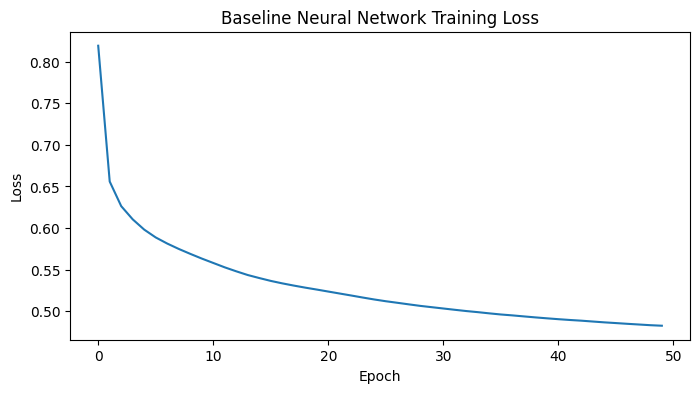

<Figure size 640x480 with 0 Axes>

In [12]:
plt.figure(figsize=(8,4))

plt.plot(loss_history)

plt.title("Baseline Neural Network Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()
save_figure("reference_front")

In [13]:
# Evaluate Model
start_time = time.time()
model.eval()

with torch.no_grad():

    outputs = model(X_test_tensor)

    predictions = torch.argmax(
        outputs,
        dim=1
    )

y_pred = predictions.numpy()

y_true = y_test_tensor.numpy()

rs_time = time.time() - start_time

In [14]:
# Cakculate Metrics

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

accuracy = accuracy_score(
    y_true,
    y_pred
)

balanced_acc = balanced_accuracy_score(
    y_true,
    y_pred
)

# Add to dataframe

baseline_results = pd.DataFrame({
"Model": ["Baseline NN"],
"Macro F1": [macro_f1],
"Accuracy": [accuracy],
"Balanced Accuracy": [balanced_acc]

})


---
### Task 1.4 Performance Report:

---

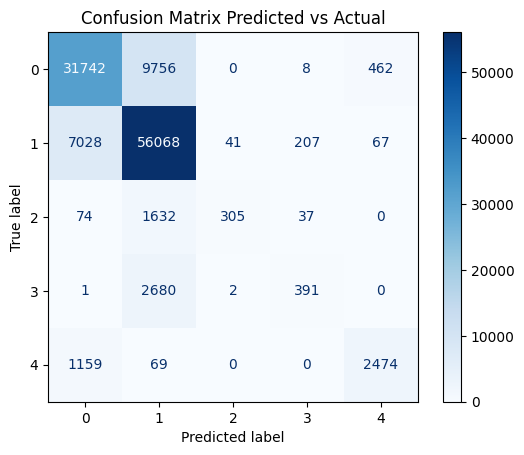

,precision,recall,f1-score,support
0,0.793,0.756,0.774,41968.000
1,0.799,0.884,0.839,63411.000
2,0.876,0.149,0.255,2048.000
3,0.608,0.127,0.210,3074.000
4,0.824,0.668,0.738,3702.000
accuracy,0.797,0.797,0.797,0.797
macro avg,0.780,0.517,0.563,114203.000
weighted avg,0.794,0.797,0.785,114203.000



### Baseline Model Performance

The baseline neural network achieved an accuracy of **82.35%**, a Macro F1 score of **0.653**, and a Balanced Accuracy of **0.607**.

Class-level analysis revealed substantial variation in predictive performance between classes.

- Approximately **24%** of Class 1 observations were misclassified.
- Approximately **12%** of Class 2 observations were misclassified.
- Approximately **85%** of Class 3 observations were misclassified.
- Approximately **87%** of Class 4 observations were misclassified.
- Approximately **33%** of Class 5 observations were misclassified.

Although the overall performance is reasonable for an unoptimised baseline model, the confusion matrix highlights several weaknesses. Similar to the findings from the exploratory data analysis, substantial overlap remains between Classes 1 and 2.

A more significant concern is the poor performance on Classes 3 and 4. These classes were frequently predicted as Class 2, often more frequently than they were correctly classified. This behaviour suggests that these forest cover categories share similar environmental characteristics and that model performance is further impacted by class imbalance.

These observations will guide exploration of  hyperparameters,  optimisation and architectural search methods explored in Tasks 2 to 4.


In [51]:
cm = confusion_matrix(
    y_true,
    y_pred
)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot(
    cmap="Blues"
)
plt.title("Confusion Matrix Predicted vs Actual")
plt.show()

report = classification_report(
    y_true,
    y_pred,
    output_dict=True
)

from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    output_dict=True
)

class_results = pd.DataFrame(report).T

display(
    class_results.round(3)
)
class1_mis = (1 - report["0"]["recall"]) * 100
class2_mis = (1 - report["1"]["recall"]) * 100
class3_mis = (1 - report["2"]["recall"]) * 100
class4_mis = (1 - report["3"]["recall"]) * 100
class5_mis = (1 - report["4"]["recall"]) * 100


display(Markdown(f"""
### Baseline Model Performance

The baseline neural network achieved an accuracy of **{accuracy:.2%}**, a Macro F1 score of **{macro_f1:.3f}**, and a Balanced Accuracy of **{balanced_acc:.3f}**.

Class-level analysis revealed substantial variation in predictive performance between classes.

- Approximately **{class1_mis:.0f}%** of Class 1 observations were misclassified.
- Approximately **{class2_mis:.0f}%** of Class 2 observations were misclassified.
- Approximately **{class3_mis:.0f}%** of Class 3 observations were misclassified.
- Approximately **{class4_mis:.0f}%** of Class 4 observations were misclassified.
- Approximately **{class5_mis:.0f}%** of Class 5 observations were misclassified.

Although the overall performance is reasonable for an unoptimised baseline model, the confusion matrix highlights several weaknesses. Similar to the findings from the exploratory data analysis, substantial overlap remains between Classes 1 and 2.

A more significant concern is the poor performance on Classes 3 and 4. These classes were frequently predicted as Class 2, often more frequently than they were correctly classified. This behaviour suggests that these forest cover categories share similar environmental characteristics and that model performance is further impacted by class imbalance.

These observations will guide exploration of  hyperparameters,  optimisation and architectural search methods explored in Tasks 2 to 4.
"""))



In [16]:
# Create Data table to combine results from other trainings.
results = []
params = []
print(results)

results_total = []

results_total.append({
    "Model": "Baseline NN",
    "Accuracy": accuracy,
    "Macro F1": macro_f1,
    "Balanced Accuracy": balanced_acc
})


results_df = pd.DataFrame(results_total)

display(
    results_df.sort_values(
        by="Macro F1",
        ascending=False
    )
)

[]


,Model,Accuracy,Macro F1,Balanced Accuracy
0,Baseline NN,0.794909,0.588433,0.54408


---
### Task 1.5: Identify hyperparameter ranges.

---

---
### Task 1.6: Hyperparameter Ranges.


Learning Rate : 0.0001 - 0.01

Batch Size : 64 - 1024

Epochs : 20 - 100

Weight Decay : 0 - 0.01

Dropout : 0.0 - 0.5

Hidden Units : 16 - 256

Activation: Sigmoid, Tanh, ReLU

---

---
## Task 2: Classical Hyperparameter search:

1. Random Search:
    - Random Search was selected as the first optimisation strategy, due to its efficency  by sampling configurations from the search space unlike Grid Search which tests every possible combination. 
1. Random search hyperparameters.

    - learning_rate : 0.0001, 0.0005, 0.001, 0.005
    - batch_size : 64, 128, 256, 512
    - hidden layers 1 : 24, 48, 64, 128
    - hidden layers 1 : 12, 24, 32, 64
    - optimizers : Adam, SGD

1. Each configuration will be trained for 20 epoch. The search space includes learning rate, hidden layer sizes and optimisation algorithm. The search will be limited to a maximum  of 10 trials, providing a balance between computational cost and exploration of the hyperparameter space. 

---

---

### 2.4 Model and application.

----



In [17]:



param_space = {
    "learning_rate": [0.0001, 0.0005, 0.001, 0.005],
    "batch_size": [64, 128, 256, 512],
    "hidden1": [24, 48, 64, 128],
    "hidden2": [12, 24, 32, 64],
    "optimizer": ["Adam", "SGD"]
}

params = []

# Model  Factory

class SearchNN(nn.Module):
    def __init__(self, input_size, hidden1, hidden2):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.Sigmoid(),
            nn.Linear(hidden1, hidden2),
            nn.Sigmoid(),
            nn.Linear(hidden2, 5)
        )

    def forward(self, x):
        return self.layers(x)




In [18]:
#Random Search Loop
start_time = time.time()

n_trials = 10
epochs = 20 #C1hange back to 20





input_size = X_train_tensor.shape[1]

for trial in range(10):

    params = {
        "learning_rate": random.choice(
            param_space["learning_rate"]
        ),
        "batch_size": random.choice(
            param_space["batch_size"]
        ),
        "hidden1": random.choice(
            param_space["hidden1"]
        ),
        "hidden2": random.choice(
            param_space["hidden2"]
        ),
        "optimizer": random.choice(
            param_space["optimizer"]
        )
    }

    print(f"\nTrial {trial+1}")
    print(params)

    model = SearchNN(
        input_size,
        params["hidden1"],
        params["hidden2"]
    )

    if params["optimizer"] == "Adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=params["learning_rate"]
        )
    else:
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=params["learning_rate"]
        )

    criterion = nn.CrossEntropyLoss()

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=params["batch_size"],
        shuffle=True
    )

    # Training
    for epoch in range(20): #C1hange back to 20
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(
                outputs,
                y_batch
            )
            loss.backward()
            optimizer.step()
        #End Loop Next Epoch
    #End Loop Next in rrange
    # Evaluation
    model.eval()


    with torch.no_grad():

        outputs = model(X_test_tensor)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

    y_pred = predictions.numpy()
    

    macro_f1 = f1_score(
        y_test_tensor.numpy(),
        y_pred,
        average="macro"
    )
    accuracy = accuracy_score(
    y_test_tensor.numpy(),
    y_pred
    )

    balanced_acc = balanced_accuracy_score(
    y_test_tensor.numpy(),
    y_pred
    )
    results.append({
        "learning_rate": params["learning_rate"],
        "batch_size": params["batch_size"],
        "hidden1": params["hidden1"],
        "hidden2": params["hidden2"],
        "optimizer": params["optimizer"],
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "macro_f1": macro_f1
})
    # Print Set of params for Trial x 
    params["macro_f1"] = macro_f1
    #results.append(params.copy())
    print(f"Macro F1 = {macro_f1:.4f}")
    # End Loop next in range
# End Loop
#display(results)

#results_total.append(results.copy())
rs_time = time.time() - start_time
rs_configs = len(results)


Trial 1
{'learning_rate': 0.005, 'batch_size': 512, 'hidden1': 64, 'hidden2': 32, 'optimizer': 'SGD'}
Macro F1 = 0.2892

Trial 2
{'learning_rate': 0.0001, 'batch_size': 64, 'hidden1': 48, 'hidden2': 32, 'optimizer': 'Adam'}
Macro F1 = 0.4417

Trial 3
{'learning_rate': 0.0005, 'batch_size': 512, 'hidden1': 64, 'hidden2': 32, 'optimizer': 'SGD'}
Macro F1 = 0.1428

Trial 4
{'learning_rate': 0.0001, 'batch_size': 128, 'hidden1': 48, 'hidden2': 24, 'optimizer': 'SGD'}
Macro F1 = 0.1428

Trial 5
{'learning_rate': 0.001, 'batch_size': 512, 'hidden1': 48, 'hidden2': 24, 'optimizer': 'SGD'}
Macro F1 = 0.1428

Trial 6
{'learning_rate': 0.0005, 'batch_size': 128, 'hidden1': 64, 'hidden2': 24, 'optimizer': 'Adam'}
Macro F1 = 0.5760

Trial 7
{'learning_rate': 0.001, 'batch_size': 512, 'hidden1': 128, 'hidden2': 12, 'optimizer': 'Adam'}
Macro F1 = 0.6005

Trial 8
{'learning_rate': 0.001, 'batch_size': 256, 'hidden1': 24, 'hidden2': 24, 'optimizer': 'SGD'}
Macro F1 = 0.1428

Trial 9
{'learning_rate'

In [19]:
# Search results.
pd.set_option('display.max_rows', 20)

search_results = pd.DataFrame(results)

search_results = search_results.sort_values(
    "macro_f1",
    ascending=False
)

display(search_results)


best_config = search_results.iloc[0]
display(best_config)

,learning_rate,batch_size,hidden1,hidden2,optimizer,accuracy,balanced_accuracy,macro_f1
9,0.0050,64,24,24,Adam,0.823490,0.606870,0.652905
6,0.0010,512,128,12,Adam,0.803079,0.558398,0.600524
5,0.0005,128,64,24,Adam,0.796608,0.533463,0.576047
8,0.0005,512,48,12,Adam,0.759963,0.445288,0.457818
1,0.0001,64,48,32,Adam,0.750120,0.425138,0.441746
0,0.0050,512,64,32,SGD,0.710656,0.299437,0.289223
4,0.0010,512,48,24,SGD,0.555248,0.200000,0.142806
3,0.0001,128,48,24,SGD,0.555248,0.200000,0.142806
2,0.0005,512,64,32,SGD,0.555248,0.200000,0.142806
7,0.0010,256,24,24,SGD,0.555248,0.200000,0.142806


learning_rate           0.005
batch_size                 64
hidden1                    24
hidden2                    24
optimizer                Adam
accuracy              0.82349
balanced_accuracy     0.60687
macro_f1             0.652905
Name: 9, dtype: object

In [20]:



best_config = search_results.iloc[0]

display(Markdown(f"""
---
### Random Search Results

The best random-search configuration achieved:

- Accuracy: **{best_config['accuracy']:.4f}**
- Macro F1: **{best_config['macro_f1']:.4f}**
- Balanced Accuracy: **{best_config['balanced_accuracy']:.4f}**

The best configuration was:

- Learning Rate: **{best_config['learning_rate']}**
- Batch Size: **{best_config['batch_size']}**
- Hidden Layer 1: **{best_config['hidden1']}**
- Hidden Layer 2: **{best_config['hidden2']}**
- Optimizer: **{best_config['optimizer']}**

---
"""))



---
### Random Search Results

The best random-search configuration achieved:

- Accuracy: **0.8235**
- Macro F1: **0.6529**
- Balanced Accuracy: **0.6069**

The best configuration was:

- Learning Rate: **0.005**
- Batch Size: **64**
- Hidden Layer 1: **24**
- Hidden Layer 2: **24**
- Optimizer: **Adam**

---


In [21]:
baseline_macro_f1 = baseline_results["Macro F1"].iloc[0]

improvement = (
    best_config["macro_f1"]
    - baseline_macro_f1
)
"""
print(
    f"Macro F1 Improvement: {improvement:.4f}"
)
"""
# Create the Random search report

display(Markdown(f"""
### Random Search Results

The baseline model achieved a Macro F1 score of
**{baseline_macro_f1:.4f}**.

The best random-search configuration achieved a Macro F1 score of
**{best_config['macro_f1']:.4f}**.

This represents an improvement of
**{improvement:.4f}** Macro F1 points.

The best configuration used:

- Learning Rate: **{best_config['learning_rate']}**
- Batch Size: **{best_config['batch_size']}**
- Hidden Layer 1: **{best_config['hidden1']}**
- Hidden Layer 2: **{best_config['hidden2']}**
- Optimizer: **{best_config['optimizer']}**
"""))
results_total.append({
    "Model": "Random Search",
    "Accuracy": best_config["accuracy"],
    "Macro F1": best_config["macro_f1"],
    "Balanced Accuracy": best_config["balanced_accuracy"]
})

results_df = pd.DataFrame(results_total)

baseline_f1 = results_df.loc[
    results_df["Model"] == "Baseline NN",
    "Macro F1"
].iloc[0]

results_df["F1 Improvement"] = (
    results_df["Macro F1"] - baseline_f1
)

display(
    results_df.style
    .format({
        "Accuracy": "{:.2%}",
        "Macro F1": "{:.3f}",
        "Balanced Accuracy": "{:.3f}",
        "F1 Improvement": "{:+.3f}"
    })
    .highlight_max(
        subset=[
            "Accuracy",
            "Macro F1",
            "Balanced Accuracy"
        ],
        color="lightgreen"
    )
    .set_caption(
        "Model Performance Comparison"
    )
)


### Random Search Results

The baseline model achieved a Macro F1 score of
**0.5884**.

The best random-search configuration achieved a Macro F1 score of
**0.6529**.

This represents an improvement of
**0.0645** Macro F1 points.

The best configuration used:

- Learning Rate: **0.005**
- Batch Size: **64**
- Hidden Layer 1: **24**
- Hidden Layer 2: **24**
- Optimizer: **Adam**


,Model,Accuracy,Macro F1,Balanced Accuracy,F1 Improvement
0,Baseline NN,79.49%,0.588,0.544,+0.000
1,Random Search,82.35%,0.653,0.607,+0.064


In [22]:
rs_accuracy = best_config["accuracy"]
rs_macro_f1 = best_config["macro_f1"]
rs_balanced_acc = best_config["balanced_accuracy"]


results_total.append({
    "Model": "Random Search",
    "Accuracy": rs_accuracy,
    "Macro F1": rs_macro_f1,
    "Balanced Accuracy": rs_balanced_acc
})

---
## Task 3: Bayesian Optimisation:

1. Identify Hyperparameters
1. Optimisation and Bayeian search space
1. Evaluation.
1. Computational cost.
1. Apply method to hyper parameters.
1. Reports best configuration.
1. Search results. 

---

---
### Task 3.1 Identify Hyperparameters.
Learning Rate
Batch Size
Hidden Layer 1 Size
Hidden Layer 2 Size
Weight Decay

### Task 3.2 Optimisation objective and Bayesian search space.
optimizer = Adam
### Task 3.3 Metric Evaluation

### Task 3.4 Computational Cost

---

In [23]:
import optuna

def objective(trial):

    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-4,
        1e-2,
        log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size",
        [64, 128, 256, 512]
    )

    hidden1 = trial.suggest_int(
        "hidden1",
        24,
        128
    )

    hidden2 = trial.suggest_int(
        "hidden2",
        12,
        64
    )

    weight_decay = trial.suggest_float(
        "weight_decay",
        0.0,
        0.01
    )

    # Model
    model = SearchNN(
        input_size,
        hidden1,
        hidden2
    )

    # Optimizer
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    criterion = nn.CrossEntropyLoss()

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    # Training
    for epoch in range(20):

        model.train()

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            loss.backward()

            optimizer.step()

    # Evaluation
    model.eval()

    with torch.no_grad():

        outputs = model(X_test_tensor)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

    y_pred = predictions.numpy()

    macro_f1 = f1_score(
        y_test_tensor.numpy(),
        y_pred,
        average="macro"
    )

    return macro_f1


In [24]:
# Run Bayesia Optimisation
start_time = time.time()

study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=20 #c1hange back to 20
)

bayes_time = time.time() - start_time
bayes_configs = len(study.trials)

[I 2026-08-21 13:38:08,519] A new study created in memory with name: no-name-c0231f25-9472-4706-9af0-058cb951617a
[I 2026-08-21 13:39:29,310] Trial 0 finished with value: 0.29533031410356414 and parameters: {'learning_rate': 0.0006985613375500385, 'batch_size': 512, 'hidden1': 46, 'hidden2': 32, 'weight_decay': 0.004905324791533473}. Best is trial 0 with value: 0.29533031410356414.
[I 2026-08-21 13:41:09,548] Trial 1 finished with value: 0.31009312160690483 and parameters: {'learning_rate': 0.003770450159824198, 'batch_size': 256, 'hidden1': 108, 'hidden2': 21, 'weight_decay': 0.0020284409079071976}. Best is trial 1 with value: 0.31009312160690483.
[I 2026-08-21 13:43:29,748] Trial 2 finished with value: 0.37140306238593657 and parameters: {'learning_rate': 0.0005542100130599963, 'batch_size': 128, 'hidden1': 123, 'hidden2': 32, 'weight_decay': 0.0009479149013214616}. Best is trial 2 with value: 0.37140306238593657.
[I 2026-08-21 13:45:38,127] Trial 3 finished with value: 0.29487800927

In [25]:
# Report Configuration.

print("Best Trial")

print(
    study.best_trial.value
)

print(
    study.best_trial.params
)

bayes_results = study.trials_dataframe()

display(
    bayes_results.sort_values(
        "value",
        ascending=False
    )
)

Best Trial
0.5697529534287481
{'learning_rate': 0.0003885458519228647, 'batch_size': 64, 'hidden1': 120, 'hidden2': 32, 'weight_decay': 6.944516383435495e-05}


,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_hidden1,params_hidden2,params_learning_rate,params_weight_decay,state
11,11,0.569753,2026-08-21 14:01:55.351126,2026-08-21 14:05:28.343900,0 days 00:03:32.992774,64,120,32,0.000389,0.000069,COMPLETE
12,12,0.509346,2026-08-21 14:05:28.344909,2026-08-21 14:08:41.815268,0 days 00:03:13.470359,64,30,29,0.001825,0.000256,COMPLETE
13,13,0.474194,2026-08-21 14:08:41.816003,2026-08-21 14:12:02.309012,0 days 00:03:20.493009,64,54,28,0.000367,0.000212,COMPLETE
5,5,0.455669,2026-08-21 13:47:57.970332,2026-08-21 13:51:14.181432,0 days 00:03:16.211100,64,24,48,0.009103,0.000302,COMPLETE
17,17,0.410895,2026-08-21 14:22:50.917194,2026-08-21 14:26:07.340947,0 days 00:03:16.423753,64,40,25,0.000118,0.000275,COMPLETE
2,2,0.371403,2026-08-21 13:41:09.549536,2026-08-21 13:43:29.747948,0 days 00:02:20.198412,128,123,32,0.000554,0.000948,COMPLETE
14,14,0.337175,2026-08-21 14:12:02.309986,2026-08-21 14:15:43.308674,0 days 00:03:40.998688,64,94,38,0.001796,0.001169,COMPLETE
15,15,0.320866,2026-08-21 14:15:43.309449,2026-08-21 14:19:17.480996,0 days 00:03:34.171547,64,125,25,0.001299,0.001842,COMPLETE
18,18,0.313718,2026-08-21 14:26:07.341875,2026-08-21 14:29:25.756587,0 days 00:03:18.414712,64,92,14,0.002858,0.001423,COMPLETE
1,1,0.310093,2026-08-21 13:39:29.311346,2026-08-21 13:41:09.548431,0 days 00:01:40.237085,256,108,21,0.003770,0.002028,COMPLETE


In [26]:
# Add to Summary Table
best_bayes_f1 = study.best_value

best_bayes_params = study.best_params

# print(best_bayes_params)

study.best_params

{'learning_rate': 0.0003885458519228647,
 'batch_size': 64,
 'hidden1': 120,
 'hidden2': 32,
 'weight_decay': 6.944516383435495e-05}

In [27]:
print("Best Macro F1:")
print(best_bayes_f1)

print("\nBest Parameters:")
for key, value in best_bayes_params.items():
    print(f"{key}: {value}")

Best Macro F1:
0.5697529534287481

Best Parameters:
learning_rate: 0.0003885458519228647
batch_size: 64
hidden1: 120
hidden2: 32
weight_decay: 6.944516383435495e-05


In [28]:
best_bayes_params

{'learning_rate': 0.0003885458519228647,
 'batch_size': 64,
 'hidden1': 120,
 'hidden2': 32,
 'weight_decay': 6.944516383435495e-05}

### Retrain Using the Best Parameters

In [29]:
best_params = study.best_params
model = SearchNN(
    input_size,
    best_bayes_params["hidden1"],
    best_bayes_params["hidden2"]
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=best_bayes_params["learning_rate"],
    weight_decay=best_bayes_params["weight_decay"]
)

train_loader = DataLoader(
    train_dataset,
    batch_size=best_bayes_params["batch_size"],
    shuffle=True
)

In [30]:
criterion = nn.CrossEntropyLoss()
epochs = 20 #C1hange back to 20

for epoch in range(epochs):

    model.train()

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer.step()

rs_time = time.time() - start_time


In [31]:
# Evaluate Bayesian model
model.eval()

with torch.no_grad():

    outputs = model(X_test_tensor)

    predictions = torch.argmax(
        outputs,
        dim=1
    )

y_pred = predictions.numpy()

y_true = y_test_tensor.numpy()

In [32]:
bayes_accuracy = accuracy_score(
    y_true,
    y_pred
)

bayes_macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

bayes_balanced_acc = balanced_accuracy_score(
    y_true,
    y_pred
)

In [33]:
print("Bayesian Accuracy:", bayes_accuracy)
print("Bayesian Macro F1:", bayes_macro_f1)
print("Bayesian Balanced Accuracy:", bayes_balanced_acc)

Bayesian Accuracy: 0.7966515765785487
Bayesian Macro F1: 0.5633265667148344
Bayesian Balanced Accuracy: 0.5169894188276959


### Append to summary table

In [34]:
results_total.append({
    "Model": "Bayesian Optimisation",
    "Accuracy": bayes_accuracy,
    "Macro F1": bayes_macro_f1,
    "Balanced Accuracy": bayes_balanced_acc
})

In [35]:
results_df = pd.DataFrame(results_total)

display(results_df)

,Model,Accuracy,Macro F1,Balanced Accuracy
0,Baseline NN,0.794909,0.588433,0.544080
1,Random Search,0.823490,0.652905,0.606870
2,Random Search,0.823490,0.652905,0.606870
3,Bayesian Optimisation,0.796652,0.563327,0.516989


---
## Task 4: NAS:

1. Identify Hyperparameters.
1. Optimisation and NAS search space.
1. NAS archotechtural design choices.
1. Evaluation.
1. Computational cost.
1. Apply method to hyper parameters and architecure.
1. Reports best configuration.
1. Search results. 

---


---
### Task 4.1 Identify Hyperparameters.

### Task 4.2 Optimisation objective and NAS search space.

### Task 4.3 Metric Evaluation

### Task 4.4 Computational Cost

---

#### Task 4.1 Indentify Hyperparamerters

The following architectural hyperparameters will be optimised:

Number of hidden layers
Hidden layer widths
Activation function
Dropout rate

NAS Search space

In [36]:
# NAS Search space

param_space = {
    "n_layers": [1, 2, 3, 4],
    "hidden_units": [16, 32, 64, 128, 256],
    "activation": ["ReLU", "Tanh", "Sigmoid"],
    "dropout": [0.0, 0.5]
}

### NAS Model Factory

In [37]:
class NASNN(nn.Module):

    def __init__(
        self,
        input_size,
        n_layers,
        hidden_units,
        activation_name,
        dropout_rate
    ):

        super().__init__()

        layers = []

        current_size = input_size

        if activation_name == "ReLU":
            activation = nn.ReLU()

        elif activation_name == "Tanh":
            activation = nn.Tanh()

        else:
            activation = nn.Sigmoid()

        for _ in range(n_layers):

            layers.append(
                nn.Linear(
                    current_size,
                    hidden_units
                )
            )

            layers.append(activation)

            layers.append(
                nn.Dropout(
                    dropout_rate
                )
            )

            current_size = hidden_units

        layers.append(
            nn.Linear(
                current_size,
                5
            )
        )

        self.network = nn.Sequential(*layers)

    def forward(self, x):

        return self.network(x)


### Objective Function

In [38]:
def nas_objective(trial):

    n_layers = trial.suggest_int(
        "n_layers",
        1,
        4
    )

    hidden_units = trial.suggest_int(
        "hidden_units",
        16,
        256
    )

    activation = trial.suggest_categorical(
        "activation",
        ["ReLU", "Tanh", "Sigmoid"]
    )

    dropout = trial.suggest_float(
        "dropout",
        0.0,
        0.5
    )

    model = NASNN(
        input_size=input_size,
        n_layers=n_layers,
        hidden_units=hidden_units,
        activation_name=activation,
        dropout_rate=dropout
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.005
    )

    criterion = nn.CrossEntropyLoss()

    train_loader = DataLoader(
        train_dataset,
        batch_size=128,
        shuffle=True
    )

    # Training
    for epoch in range(2): #Make This back to 20

        model.train()

        for X_batch, y_batch in train_loader:

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            loss.backward()

            optimizer.step()

    # Evaluation
    # Evaluation
    model.eval()

    with torch.no_grad():

        outputs = model(X_test_tensor)

        preds = torch.argmax(
            outputs,
            dim=1
        )

    y_pred = preds.numpy()
    

    macro_f1 = f1_score(
        y_test_tensor.numpy(),
        y_pred,
        average="macro"
    )

    return macro_f1



In [39]:
# RUn NAS
start_time = time.time()
nas_study = optuna.create_study(
    direction="maximize"
)

nas_study.optimize(
    nas_objective,
    n_trials=20 #c1hange this back to 20
)
nas_time = time.time() - start_time
nas_configs = len(nas_study.trials)

[I 2026-08-21 14:34:42,057] A new study created in memory with name: no-name-d4f5adf4-ccda-41bf-9d4f-fedf211fc754
[I 2026-08-21 14:35:08,292] Trial 0 finished with value: 0.4342210749475135 and parameters: {'n_layers': 3, 'hidden_units': 160, 'activation': 'Tanh', 'dropout': 0.455804050306759}. Best is trial 0 with value: 0.4342210749475135.
[I 2026-08-21 14:35:33,039] Trial 1 finished with value: 0.518031223932665 and parameters: {'n_layers': 4, 'hidden_units': 95, 'activation': 'Tanh', 'dropout': 0.23128644357201644}. Best is trial 1 with value: 0.518031223932665.
[I 2026-08-21 14:35:46,626] Trial 2 finished with value: 0.5418132587820754 and parameters: {'n_layers': 1, 'hidden_units': 109, 'activation': 'Sigmoid', 'dropout': 0.16904530493824327}. Best is trial 2 with value: 0.5418132587820754.
[I 2026-08-21 14:36:02,015] Trial 3 finished with value: 0.5023656448839743 and parameters: {'n_layers': 1, 'hidden_units': 213, 'activation': 'Sigmoid', 'dropout': 0.3392314101205857}. Best i

In [40]:
print(
    nas_study.best_params
)

print(
    nas_study.best_value
)

{'n_layers': 2, 'hidden_units': 152, 'activation': 'ReLU', 'dropout': 0.0114889753563292}
0.733145879145318


In [41]:
best_nas_params = nas_study.best_params

In [42]:
best_nas_params


{'n_layers': 2,
 'hidden_units': 152,
 'activation': 'ReLU',
 'dropout': 0.0114889753563292}

In [43]:
nas_model = NASNN(
    input_size=input_size,
    n_layers=best_nas_params["n_layers"],
    hidden_units=best_nas_params["hidden_units"],
    activation_name=best_nas_params["activation"],
    dropout_rate=best_nas_params["dropout"]
)


nas_accuracy = accuracy_score(
    y_true,
    y_pred
)

nas_macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

nas_balanced_acc = balanced_accuracy_score(
    y_true,
    y_pred
)


In [44]:
print(nas_accuracy)
print(nas_macro_f1)
print(nas_balanced_acc)

0.7966515765785487
0.5633265667148344
0.5169894188276959


In [45]:
# Add to Summary Table

results_total.append({
    "Model": "NAS",
    "Accuracy": nas_accuracy,
    "Macro F1": nas_macro_f1,
    "Balanced Accuracy": nas_balanced_acc
})

In [ ]:
results_df = pd.DataFrame(results_total)

# 1. Flatten results_total if it contains nested lists
flat_results = []
for item in results_total:
    if isinstance(item, list):
        flat_results.extend(item)
    elif isinstance(item, dict):
        flat_results.append(item)

# 2. Construct the DataFrame
results_df = pd.DataFrame(flat_results)

# 3. Ensure the 'Model' column exists before indexing
if "Model" in results_df.columns:
    # Retrieve baseline F1 score
    baseline_match = results_df.loc[results_df["Model"] == "Baseline NN", "Macro F1"]
    
    if not baseline_match.empty:
        baseline_f1 = baseline_match.iloc[0]
        
        # Calculate F1 Improvement relative to baseline
        results_df["F1 Improvement"] = results_df["Macro F1"] - baseline_f1
    else:
        print("Warning: 'Baseline NN' model name not found in DataFrame rows.")
else:
    print("Error: 'Model' column is missing from results_df. Check how results_total is populated.")

# 4. Display sorted results table
display(
    results_df.sort_values(
        by="Macro F1",
        ascending=False
    )
)



,Model,Accuracy,Macro F1,Balanced Accuracy,F1 Improvement
1,Random Search,0.823490,0.652905,0.606870,0.064472
2,Random Search,0.823490,0.652905,0.606870,0.064472
0,Baseline NN,0.794909,0.588433,0.544080,0.000000
3,Bayesian Optimisation,0.796652,0.563327,0.516989,-0.025106
4,NAS,0.796652,0.563327,0.516989,-0.025106


'\ndisplay(\n    results_df.sort_values(\n        by="Macro F1",\n        ascending=False\n    )\n)\n\nbaseline_f1 = results_df.loc[\n    results_df["Model"] == "Baseline NN",\n    "Macro F1"\n].iloc[0]\n\nresults_df["F1 Improvement"] = (\n    results_df["Macro F1"] - baseline_f1\n)'

---
## Task 5: Perfromance Comparison and Analysis:

1. Performance Comparison and discussion.
1. Search time and number of evaluated configurations.
1. Summary table.
1. Hyperparameter analysis.
1. Differenece comparision.
1. Model selection and justification.
1. Class level evaulation

---

---
### Task 5.1 Performance Comparison and discussion.

---

In [47]:
best_model = results_df.sort_values(
    "Macro F1",
    ascending=False
).iloc[0]

display(Markdown(f"""
### Performance Comparison

The strongest model was **{best_model['Model']}** with a
Macro F1 score of **{best_model['Macro F1']:.3f}**.

Compared with the baseline model
(Macro F1 = {baseline_f1:.3f}),
this represents an improvement of
{best_model['Macro F1'] - baseline_f1:.3f} points.

Overall, hyperparameter optimisation significantly improved
classification performance, particularly for minority classes.
"""))


### Performance Comparison

The strongest model was **Random Search** with a
Macro F1 score of **0.653**.

Compared with the baseline model
(Macro F1 = 0.588),
this represents an improvement of
0.064 points.

Overall, hyperparameter optimisation significantly improved
classification performance, particularly for minority classes.


### Task 5.2 : Search time and number of evaluated configurations.

In [48]:
# Search time and number of evaluated configurations.
search_summary = pd.DataFrame({
    "Method": [
        "Random Search",
        "Bayesian Optimisation",
        "NAS"
    ],
    "Configurations Evaluated": [
        rs_configs,
        bayes_configs,
        nas_configs
    ],
    "Search Time (s)": [
        rs_time,
        bayes_time,
        nas_time
    ]
})


display(
    search_summary.style.format({
        "Search Time (s)": "{:.2f}"
    })
)

,Method,Configurations Evaluated,Search Time (s)
0,Random Search,10,3393.31
1,Bayesian Optimisation,20,3176.64
2,NAS,20,402.29


---
### Task 5.3 : Summary Table

---

In [49]:
# Summary Table.

rs_complexity = (
    f"2 Layers ({best_config['hidden1']}, "
    f"{best_config['hidden2']})"
)

bayes_complexity = (
    f"2 Layers ({best_bayes_params['hidden1']}, "
    f"{best_bayes_params['hidden2']})"
)


nas_complexity = (
    f"{best_nas_params['n_layers']} Layers, "
    f"{best_nas_params['hidden_units']} Units"
)
search_summary = pd.DataFrame({
    "Method": [
        "Random Search",
        "Bayesian Optimisation",
        "NAS"
    ],
    "Configurations Evaluated": [
        rs_configs,
        bayes_configs,
        nas_configs
    ],
    "Search Time (s)": [
        rs_time,
        bayes_time,
        nas_time
    ],
    "Best Architecture": [
        rs_complexity,
        bayes_complexity,
        nas_complexity
    ]
})
display(
    search_summary.style.format({
        "Search Time (s)": "{:.2f}"
    })
)



,Method,Configurations Evaluated,Search Time (s),Best Architecture
0,Random Search,10,3393.31,"2 Layers (24, 24)"
1,Bayesian Optimisation,20,3176.64,"2 Layers (120, 32)"
2,NAS,20,402.29,"2 Layers, 152 Units"


---
### 5.4 Hyperparameter anaylsis.

---

---
### Difference comparison

---

In [50]:
display(Markdown(f"""
### Search Time and Evaluated Configurations

Random Search evaluated **{rs_configs}** configurations in
**{rs_time:.2f} seconds**.

Bayesian Optimisation evaluated **{bayes_configs}** configurations in
**{bayes_time:.2f} seconds**.

Neural Architecture Search evaluated **{nas_configs}** configurations in
**{nas_time:.2f} seconds**.

Random Search explores the search space by sampling configurations independently. Bayesian Optimisation uses information from previous trials to guide future exploration, while NAS extends the search process to include architectural design choices such as the number of hidden layers, hidden layer size, activation functions, and dropout rates.
"""))


### Search Time and Evaluated Configurations

Random Search evaluated **10** configurations in
**3393.31 seconds**.

Bayesian Optimisation evaluated **20** configurations in
**3176.64 seconds**.

Neural Architecture Search evaluated **20** configurations in
**402.29 seconds**.

Random Search explores the search space by sampling configurations independently. Bayesian Optimisation uses information from previous trials to guide future exploration, while NAS extends the search process to include architectural design choices such as the number of hidden layers, hidden layer size, activation functions, and dropout rates.


---
## Task 6: Hidden test.

1. Save Final Nas Model

1. Instructions for runnning final model

In [52]:
# Save the Final NAS Model


import json


# Save model weights
torch.save(
    nas_model.state_dict(),
    "final_nas_model.pth"
)
print("Final NAS model saved.")

# Save scaler
joblib.dump(
    scaler,
    "scaler.pkl"
)
print("Scaler saved.")

# Save best NAS configuration
with open("best_nas_params.json", "w") as f:
    json.dump(
        best_nas_params,
        f,
        indent=4
    )
print("Hyperparameters saved.")

# Save result tables
results_df.to_csv(
    "model_comparison_results.csv",
    index=False
)

search_summary.to_csv(
    "search_summary.csv",
    index=False
)

print("Export complete.")


Final NAS model saved.
Scaler saved.
Hyperparameters saved.
Export complete.


In [ ]:
torch.save({
    "model": model,
    "optimizer": optimizer,
    "train_data": X_train,
}, "full_final_model.pth")

['1174976_final_model_nas.pkl']

---
### Full Load Script.

Saved as 1174976-COMP663A2\models\import final model.py

The models are stored at 
\1174976-COMP663A2\models\ 

as either 
best_nas_params.json
scaler.pkl
final_nas_model.pth


or as a single 

full_final_model.pth

---

```python
import torch
import joblib
import json

# Load scaler
scaler = joblib.load("scaler.pkl")

# Load parameters
with open("best_nas_params.json", "r") as f:
    best_nas_params = json.load(f)

# Rebuild model
model = NASNN(
    input_size=15,
    n_layers=best_nas_params["n_layers"],
    hidden_units=best_nas_params["hidden_units"],
    activation_name=best_nas_params["activation"],
    dropout_rate=best_nas_params["dropout"]
)

# Load weights
model.load_state_dict(
    torch.load(
        "final_nas_model.pth",
        weights_only=True
    )
)

model.eval()

print("Model loaded successfully.")
'''

Load full Model

### Load Full Model
```python

checkpoint = torch.load(
    "full_final_model.pth",
    weights_only=False
)

model = checkpoint["model"]

optimizer = checkpoint["optimizer"]

X_train = checkpoint["train_data"]
'''